# Financial News Sentiment Analysis

This notebook is the cleaned project report and code submission for sentence-level sentiment classification of financial news. It compares a simple embedding average-pooling baseline against a Bidirectional LSTM with attention.


### Metadata

```yaml
project_title: "Financial News Sentiment Analysis with Bi-LSTM and Attention"
dataset_name: "Financial News Sentiment Corpus"
task_type: "Multi-class sentiment classification"
classes:
  - neutral
  - positive
  - negative
primary_metric: "validation accuracy"
models:
  - Embedding average-pooling baseline
  - Bi-LSTM with attention
```


### AI Usage Declaration

| Item | Response |
|---|---|
| Did you use generative AI tools? | Yes  |
| Which tools? | gemini |
| For what purpose? | Code review, structuring, explanations/ coding assist / debugging |
| Which parts were AI-assisted? | Documentation, architecture discussion |
| What did you verify yourself? | All code, experiments, and results |

### Short declaration
Generative AI tools were used to assist with code review, notebook structuring, and documentation clarity. All implementations were executed, tested, and validated independently.


## Data

### Problem Definition and Motivation

The goal of this project is to perform **sentence-level sentiment classification** on financial news text. Each sentence is classified as neutral, positive, or negative. This is useful because financial news can influence market perception, investor confidence, and downstream decision-support systems.


### Dataset Description

The dataset contains financial news sentences labeled with sentiment classes. The notebook loads the data directly from a public CSV file, maps sentiment labels to integer classes, and uses a stratified train/validation/test split so that class proportions remain stable across the experiment.


### Setup and Imports


In [1]:
# Core libraries
import random
import copy
import re
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_packed_sequence, pad_sequence, pack_padded_sequence
from torch.utils.data import DataLoader, Dataset


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [3]:
RANDOM_SEED = 42


def set_seed(seed=RANDOM_SEED):
    """Set random seeds so model initialization and shuffling are reproducible."""
    random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed()
print(f"Random seed: {RANDOM_SEED}")


Random seed: 42


### Data Loading


In [4]:
DATA_URL = "https://raw.githubusercontent.com/ukairia777/finance_sentiment_corpus/main/finance_data.csv"

df = pd.read_csv(DATA_URL)

print(df.head())
print(f"Total samples: {len(df)}")


     labels                                           sentence  \
0   neutral  According to Gran, the company has no plans to...   
1   neutral  Technopolis plans to develop in stages an area...   
2  negative  The international electronic industry company ...   
3  positive  With the new production plant the company woul...   
4  positive  According to the company's updated strategy fo...   

                                        kor_sentence  
0  Gran에 따르면, 그 회사는 회사가 성장하고 있는 곳이지만, 모든 생산을 러시아로...  
1  테크노폴리스는 컴퓨터 기술과 통신 분야에서 일하는 회사들을 유치하기 위해 10만 평...  
2  국제 전자산업 회사인 엘코텍은 탈린 공장에서 수십 명의 직원을 해고했으며, 이전의 ...  
3  새로운 생산공장으로 인해 회사는 예상되는 수요 증가를 충족시킬 수 있는 능력을 증가...  
4  2009-2012년 회사의 업데이트된 전략에 따르면, Basware는 20% - 4...  
Total samples: 4846


### Label Preprocessing


In [5]:
LABEL_MAPPING = {
    "neutral": 0,
    "positive": 1,
    "negative": 2,
}

NUM_CLASSES = len(LABEL_MAPPING)

df["labels"] = df["labels"].map(LABEL_MAPPING)
df = df.dropna(subset=["sentence", "labels"]).reset_index(drop=True)

print(df["labels"].value_counts())


labels
0    2879
1    1363
2     604
Name: count, dtype: int64


### Tokenization and Vocabulary


In [6]:
def tokenize(text: str):
    """Lowercase and tokenize text using a simple regex tokenizer."""
    text = text.lower()
    # Using a raw string with proper word boundaries
    return re.findall(r"\b\w+\b", text)


def build_vocab(sentences, min_freq=1):
    """Build a token vocabulary from the training sentences."""
    counter = Counter()
    for sentence in sentences:
        counter.update(tokenize(sentence))

    vocab = {"<PAD>": 0, "<UNK>": 1}
    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = len(vocab)

    return vocab


def encode_text(text, vocab):
    """Convert a sentence to token IDs."""
    return [vocab.get(token, vocab["<UNK>"]) for token in tokenize(text)]

### Dataset and DataLoaders


In [7]:
class FinancialNewsDataset(Dataset):
    """PyTorch dataset for financial news sentiment examples."""

    def __init__(self, dataframe, vocab):
        self.sentences = dataframe["sentence"].tolist()
        self.labels = dataframe["labels"].tolist()
        self.vocab = vocab

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):
        token_ids = encode_text(self.sentences[idx], self.vocab)
        label = self.labels[idx]

        return (
            torch.tensor(token_ids, dtype=torch.long),
            torch.tensor(label, dtype=torch.long),
        )


def collate_fn(batch):
    """Pad variable-length token sequences in a batch."""
    texts, labels = zip(*batch)
    lengths = torch.tensor([len(text) for text in texts], dtype=torch.long)
    texts_padded = pad_sequence(texts, batch_first=True, padding_value=0)
    labels = torch.stack(labels)
    return texts_padded, lengths, labels


In [8]:
train_df, test_val_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["labels"],
    random_state=42,
)

val_df, test_df = train_test_split(
    test_val_df,
    test_size=0.5,
    stratify=test_val_df["labels"],
    random_state=42,
)


train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

vocab = build_vocab(train_df["sentence"].tolist())
pad_idx = vocab["<PAD>"]

counts = train_df["labels"].value_counts().sort_index().values
weights = 1.0 / counts
weights = weights / weights.sum() * len(counts)
class_weights = torch.tensor(weights, dtype=torch.float)

print("Split sizes:", {"train": len(train_df), "val": len(val_df), "test": len(test_df)})
print("Class counts:", counts)
print("Class weights:", class_weights)


Split sizes: {'train': 3876, 'val': 485, 'test': 485}
Class counts: [2303 1090  483]
Class weights: tensor([0.3807, 0.8043, 1.8151])


In [9]:
BATCH_SIZE = 32

train_dataset = FinancialNewsDataset(train_df, vocab)
val_dataset = FinancialNewsDataset(val_df, vocab)
test_dataset = FinancialNewsDataset(test_df, vocab)

train_generator = torch.Generator()
train_generator.manual_seed(RANDOM_SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    generator=train_generator,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
)


## Models

### Shared Training and Evaluation Utilities


In [10]:
def get_logits(model_output):
    """Return logits from models that may also return attention weights."""
    if isinstance(model_output, tuple):
        return model_output[0]
    return model_output


def train_one_epoch(model, dataloader, criterion, optimizer, device, max_grad_norm=1.0):
    """Train a model for one epoch."""
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for batch_texts, batch_lengths, batch_labels in dataloader:
        batch_texts = batch_texts.to(device)
        batch_lengths = batch_lengths.to(device)
        batch_labels = batch_labels.to(device)

        optimizer.zero_grad()
        logits = get_logits(model(batch_texts, batch_lengths))
        loss = criterion(logits, batch_labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_grad_norm)
        optimizer.step()

        batch_size = batch_labels.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == batch_labels).sum().item()
        total_samples += batch_size

    return total_loss / total_samples, total_correct / total_samples


In [11]:
def evaluate(model, dataloader, criterion, device):
    """Evaluate a model on a validation dataloader."""
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for batch_texts, batch_lengths, batch_labels in dataloader:
            batch_texts = batch_texts.to(device)
            batch_lengths = batch_lengths.to(device)
            batch_labels = batch_labels.to(device)

            logits = get_logits(model(batch_texts, batch_lengths))
            loss = criterion(logits, batch_labels)

            batch_size = batch_labels.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (logits.argmax(dim=1) == batch_labels).sum().item()
            total_samples += batch_size

    return total_loss / total_samples, total_correct / total_samples


In [12]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=30,
    scheduler=None,
    early_stopping_patience=3,
    max_grad_norm=1.0,
):
    """Train a model with validation tracking and early stopping."""
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    best_val_acc = 0.0
    best_epoch = 0
    best_model_state = None
    epochs_without_improvement = 0

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(
            model=model,
            dataloader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device,
            max_grad_norm=max_grad_norm,
        )

        val_loss, val_acc = evaluate(
            model=model,
            dataloader=val_loader,
            criterion=criterion,
            device=device,
        )

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if scheduler is not None:
            scheduler.step(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch + 1
            best_model_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        current_lr = optimizer.param_groups[0]["lr"]
        print(
            f"Epoch [{epoch + 1}/{epochs}] | "
            f"LR: {current_lr:.6f} | "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
        )

        if epochs_without_improvement >= early_stopping_patience:
            print(f"\nEarly stopping triggered at epoch {epoch + 1}.")
            break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    print(f"\nBest Validation Accuracy: {best_val_acc:.4f} (Epoch {best_epoch})")

    return history


In [13]:
def make_plateau_scheduler(optimizer):
    """Create the ReduceLROnPlateau scheduler used by both models."""
    return torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=1,
    )


### Baseline Model

The baseline ignores word order and classifies each sentence from the masked average of its token embeddings. It provides a simple comparison point for the proposed sequence model.


In [14]:
class EmbeddingAvgPoolClassifier(nn.Module):
    """Baseline classifier using masked average pooling of embeddings."""

    def __init__(self, vocab_size, embed_dim, num_classes, pad_idx=0, dropout=0.3):
        super().__init__()
        self.pad_idx = pad_idx
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(embed_dim, num_classes)

    def forward(self, input_ids, lengths=None):
        embeddings = self.embedding(input_ids)
        mask = (input_ids != self.pad_idx).unsqueeze(-1)
        pooled = (embeddings * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-8)
        return self.fc(self.dropout(pooled))


In [15]:
def build_fresh_baseline(
    vocab,
    class_weights,
    pad_idx,
    device,
    embed_dim=100,
    dropout=0.3,
    lr=1e-3,
    weight_decay=0.0,
):
    """Create a fresh baseline model, loss function, and optimizer."""
    model = EmbeddingAvgPoolClassifier(
        vocab_size=len(vocab),
        embed_dim=embed_dim,
        num_classes=NUM_CLASSES,
        pad_idx=pad_idx,
        dropout=dropout,
    ).to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    return model, criterion, optimizer


## Training

### Training the Baseline Model


In [16]:
set_seed(RANDOM_SEED)

baseline_model, criterion_base, optimizer_base = build_fresh_baseline(
    vocab=vocab,
    pad_idx=pad_idx,
    class_weights=class_weights,
    device=device,
    embed_dim=100,
    dropout=0.3,
    lr=1e-3,
    weight_decay=1e-5,
)

scheduler_base = make_plateau_scheduler(optimizer_base)

history_baseline = train_model(
    model=baseline_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion_base,
    optimizer=optimizer_base,
    device=device,
    epochs=30,
    scheduler=scheduler_base,
    early_stopping_patience=3,
    max_grad_norm=1.0,
)


Epoch [1/30] | LR: 0.001000 | Train Loss: 1.0697, Train Acc: 0.4592 | Val Loss: 1.0285, Val Acc: 0.5134


Epoch [2/30] | LR: 0.001000 | Train Loss: 1.0159, Train Acc: 0.5459 | Val Loss: 0.9806, Val Acc: 0.5732


Epoch [3/30] | LR: 0.001000 | Train Loss: 0.9659, Train Acc: 0.5980 | Val Loss: 0.9364, Val Acc: 0.5979


Epoch [4/30] | LR: 0.001000 | Train Loss: 0.9154, Train Acc: 0.6331 | Val Loss: 0.8970, Val Acc: 0.6124


Epoch [5/30] | LR: 0.001000 | Train Loss: 0.8660, Train Acc: 0.6535 | Val Loss: 0.8587, Val Acc: 0.6247


...

Epoch [14/30] | LR: 0.000500 | Train Loss: 0.4580, Train Acc: 0.8359 | Val Loss: 0.6609, Val Acc: 0.7155


Epoch [15/30] | LR: 0.000500 | Train Loss: 0.4307, Train Acc: 0.8491 | Val Loss: 0.6565, Val Acc: 0.7175


Epoch [16/30] | LR: 0.000500 | Train Loss: 0.4232, Train Acc: 0.8491 | Val Loss: 0.6515, Val Acc: 0.7155


Epoch [17/30] | LR: 0.000250 | Train Loss: 0.4094, Train Acc: 0.8596 | Val Loss: 0.6482, Val Acc: 0.7155


Epoch [18/30] | LR: 0.000250 | Train Loss: 0.3900, Train Acc: 0.8625 | Val Loss: 0.6466, Val Acc: 0.7155

Early stopping triggered at epoch 18.

Best Validation Accuracy: 0.7175 (Epoch 15)


### Bi-LSTM with Attention

The proposed model uses a Bidirectional LSTM to encode each sentence and an attention layer to weight token representations before classification.


In [17]:
class BiLSTMAttentionClassifier(nn.Module):
    """Bidirectional LSTM with attention for sentence classification."""

    def __init__(
        self,
        vocab_size,
        embed_dim,
        hidden_dim,
        num_classes,
        pad_idx=0,
        num_layers=1,
        dropout=0.3,
    ):
        super().__init__()
        self.pad_idx = pad_idx

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=pad_idx,
        )

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.attention = nn.Linear(hidden_dim * 2, 1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, input_ids, lengths=None):
        embeddings = self.embedding(input_ids)

        if lengths is not None:
            packed_embeddings = pack_padded_sequence(
                embeddings,
                lengths.cpu(),
                batch_first=True,
                enforce_sorted=False,
            )
            packed_out, _ = self.lstm(packed_embeddings)
            lstm_out, _ = pad_packed_sequence(
                packed_out,
                batch_first=True,
                total_length=input_ids.size(1),
            )
        else:
            lstm_out, _ = self.lstm(embeddings)

        mask = input_ids != self.pad_idx
        attention_scores = self.attention(lstm_out).squeeze(-1)
        attention_scores = attention_scores.masked_fill(~mask, -1e9)
        attention_weights = F.softmax(attention_scores, dim=1)

        context = torch.bmm(attention_weights.unsqueeze(1), lstm_out).squeeze(1)
        logits = self.fc(self.dropout(context))

        return logits, attention_weights


In [18]:
def build_fresh_attn_model(
    vocab,
    pad_idx,
    class_weights,
    device,
    embed_dim=100,
    hidden_dim=98,
    dropout=0.3,
    lr=1e-3,
    weight_decay=0.0,
):
    """Create a fresh Bi-LSTM attention model, loss function, and optimizer."""
    model = BiLSTMAttentionClassifier(
        vocab_size=len(vocab),
        embed_dim=embed_dim,
        hidden_dim=hidden_dim,
        num_classes=NUM_CLASSES,
        pad_idx=pad_idx,
        dropout=dropout,
    ).to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    return model, criterion, optimizer


In [19]:
set_seed(RANDOM_SEED)

attn_model, criterion_attn, optimizer_attn = build_fresh_attn_model(
    vocab=vocab,
    pad_idx=pad_idx,
    class_weights=class_weights,
    device=device,
    embed_dim=100,
    hidden_dim=98,
    dropout=0.5,
    lr=1e-3,
    weight_decay=1e-5,
)


### Attention Forward-Pass Check


In [20]:
batch_texts, batch_lengths, batch_labels = next(iter(train_loader))
batch_texts = batch_texts.to(device)
batch_lengths = batch_lengths.to(device)
batch_labels = batch_labels.to(device)

logits, attention_weights = attn_model(batch_texts, batch_lengths)

print("Input shape:", batch_texts.shape)
print("Logits shape:", logits.shape)
print("Attention weights shape:", attention_weights.shape)
print("Attention row sums (first 5):", attention_weights.sum(dim=1)[:5])


Input shape: torch.Size([32, 43])
Logits shape: torch.Size([32, 3])
Attention weights shape: torch.Size([32, 43])
Attention row sums (first 5): tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000], grad_fn=<SliceBackward0>)


In [21]:
assert logits.shape == (batch_texts.size(0), NUM_CLASSES)
assert attention_weights.shape == batch_texts.shape

row_sums = attention_weights.sum(dim=1)
ones = torch.ones_like(row_sums)
assert torch.allclose(row_sums, ones, atol=1e-4), "Attention weights do not sum to 1."

print("Forward pass is correct.")


Forward pass is correct.


### Training the Bi-LSTM Attention Model


In [22]:
scheduler_attn = make_plateau_scheduler(optimizer_attn)

history_attn = train_model(
    model=attn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion_attn,
    optimizer=optimizer_attn,
    device=device,
    epochs=30,
    scheduler=scheduler_attn,
    early_stopping_patience=3,
    max_grad_norm=1.0,
)


Epoch [1/30] | LR: 0.001000 | Train Loss: 1.0191, Train Acc: 0.5614 | Val Loss: 0.9070, Val Acc: 0.5918


Epoch [2/30] | LR: 0.001000 | Train Loss: 0.7881, Train Acc: 0.6718 | Val Loss: 0.7417, Val Acc: 0.6845


Epoch [3/30] | LR: 0.001000 | Train Loss: 0.5813, Train Acc: 0.7570 | Val Loss: 0.7243, Val Acc: 0.6639


Epoch [4/30] | LR: 0.001000 | Train Loss: 0.4379, Train Acc: 0.8130 | Val Loss: 0.7348, Val Acc: 0.7134


Epoch [5/30] | LR: 0.001000 | Train Loss: 0.3043, Train Acc: 0.8633 | Val Loss: 0.8984, Val Acc: 0.7093


Epoch [6/30] | LR: 0.001000 | Train Loss: 0.2040, Train Acc: 0.9169 | Val Loss: 0.9816, Val Acc: 0.7196


Epoch [7/30] | LR: 0.001000 | Train Loss: 0.1320, Train Acc: 0.9515 | Val Loss: 1.0847, Val Acc: 0.7320


Epoch [8/30] | LR: 0.001000 | Train Loss: 0.0823, Train Acc: 0.9719 | Val Loss: 1.4020, Val Acc: 0.6990


Epoch [9/30] | LR: 0.000500 | Train Loss: 0.0536, Train Acc: 0.9817 | Val Loss: 1.7616, Val Acc: 0.7113


Epoch [10/30] | LR: 0.000500 | Train Loss: 0.0320, Train Acc: 0.9912 | Val Loss: 1.7041, Val Acc: 0.7155

Early stopping triggered at epoch 10.

Best Validation Accuracy: 0.7320 (Epoch 7)


### Training Curves and Model Comparison


In [23]:
def plot_training_curves(history, model_name="Model"):
    """Plot training and validation loss/accuracy curves."""
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], marker="o", label="Train Loss")
    plt.plot(epochs, history["val_loss"], marker="o", label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{model_name} Loss")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], marker="o", label="Train Accuracy")
    plt.plot(epochs, history["val_acc"], marker="o", label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{model_name} Accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


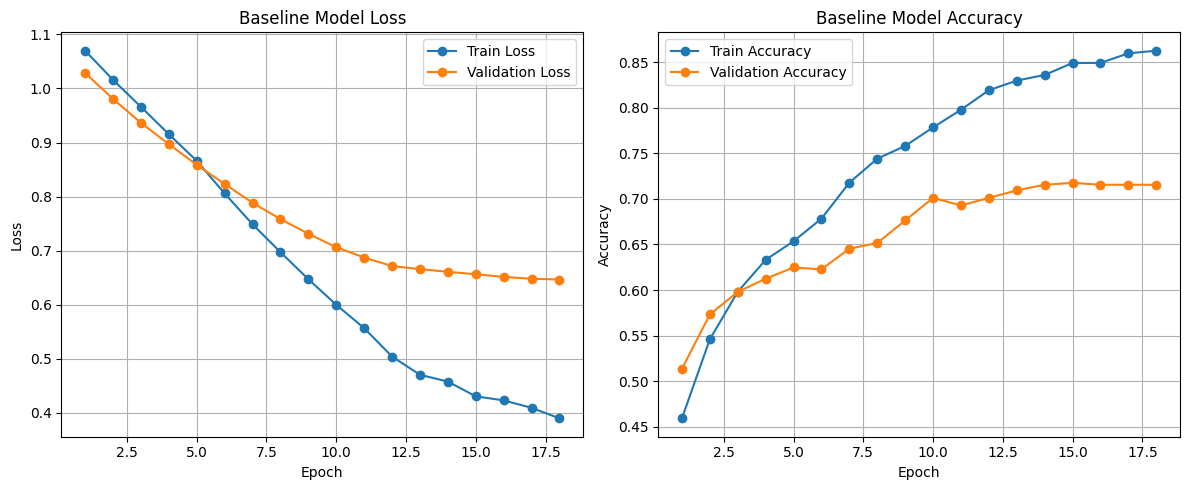

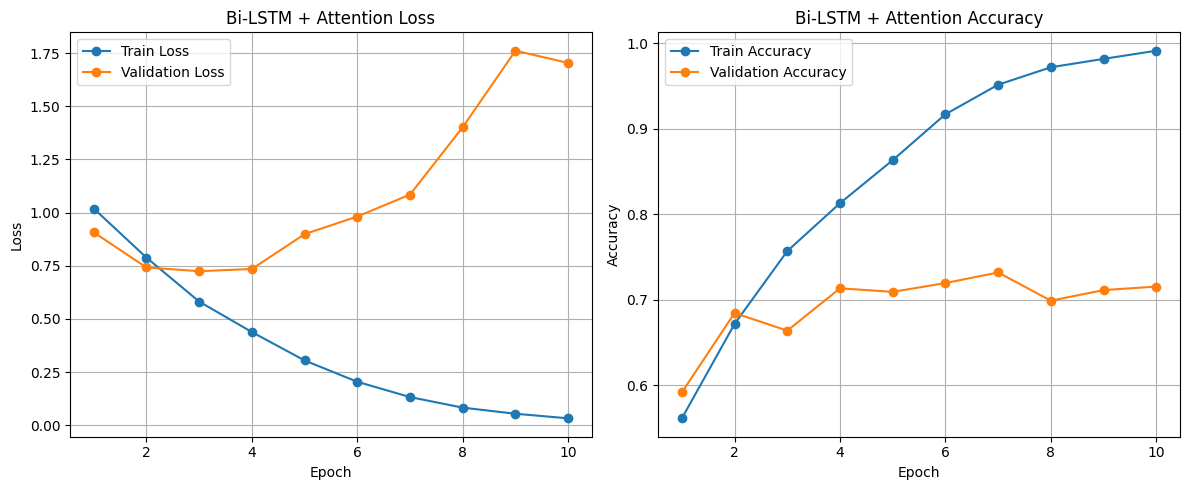

In [24]:
plot_training_curves(history_baseline, model_name="Baseline Model")
plot_training_curves(history_attn, model_name="Bi-LSTM + Attention")


In [25]:
best_baseline_val_acc = max(history_baseline["val_acc"])
best_attn_val_acc = max(history_attn["val_acc"])

print(f"Best Baseline Validation Accuracy: {best_baseline_val_acc:.4f}")
print(f"Best Bi-LSTM + Attention Validation Accuracy: {best_attn_val_acc:.4f}")


Best Baseline Validation Accuracy: 0.7175
Best Bi-LSTM + Attention Validation Accuracy: 0.7320


In [26]:
def plot_model_comparison(history_a, history_b, name_a="Baseline", name_b="Bi-LSTM + Attention"):
    """Plot validation curves for two models on the same figure."""
    epochs_a = range(1, len(history_a["val_acc"]) + 1)
    epochs_b = range(1, len(history_b["val_acc"]) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_a, history_a["val_loss"], marker="o", label=f"{name_a} Val Loss")
    plt.plot(epochs_b, history_b["val_loss"], marker="o", label=f"{name_b} Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Validation Loss Comparison")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_a, history_a["val_acc"], marker="o", label=f"{name_a} Val Accuracy")
    plt.plot(epochs_b, history_b["val_acc"], marker="o", label=f"{name_b} Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Validation Accuracy Comparison")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


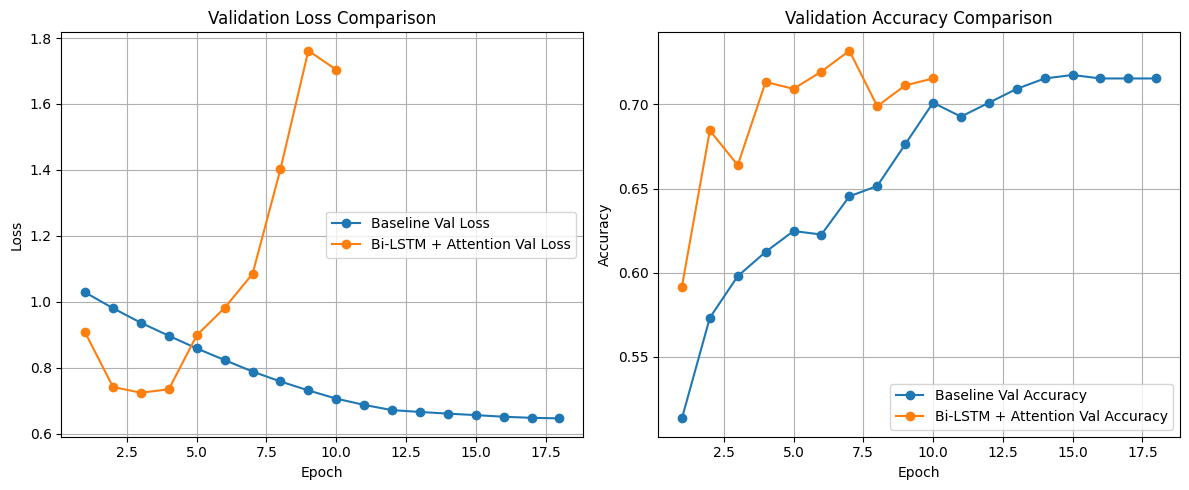

In [27]:
plot_model_comparison(
    history_baseline,
    history_attn,
    name_a="Baseline",
    name_b="Bi-LSTM + Attention",
)


### Final Test Evaluation


In [28]:
baseline_test_loss, baseline_test_acc = evaluate(
    baseline_model,
    test_loader,
    criterion_base,
    device,
)

attn_test_loss, attn_test_acc = evaluate(
    attn_model,
    test_loader,
    criterion_attn,
    device,
)

print(f"Baseline Test Loss: {baseline_test_loss:.4f}, Test Accuracy: {baseline_test_acc:.4f}")
print(f"Bi-LSTM + Attention Test Loss: {attn_test_loss:.4f}, Test Accuracy: {attn_test_acc:.4f}")


Baseline Test Loss: 0.7879, Test Accuracy: 0.7216
Bi-LSTM + Attention Test Loss: 1.3441, Test Accuracy: 0.7402


## XAI Showcase

This section uses the trained Bi-LSTM attention model to inspect which tokens receive the highest attention weights during prediction. The examples are selected from the held-out test split so the visualization is based on sentences that were not used for training.


In [29]:
FINANCIAL_KEYWORDS = {
    "revenue", "revenues", "profit", "profits", "loss", "losses", "sales",
    "growth", "market", "markets", "share", "shares", "stock", "stocks",
    "acquisition", "earnings", "income", "margin", "margins", "demand",
    "investment", "investments", "price", "prices", "cost", "costs",
}

ID_TO_LABEL = {idx: label for label, idx in LABEL_MAPPING.items()}


def score_xai_candidate(sentence):
    """Score sentences by financial keyword coverage and descriptive length."""
    tokens = tokenize(sentence)
    keyword_hits = sum(token in FINANCIAL_KEYWORDS for token in tokens)
    descriptive_length = min(len(tokens), 40)
    return keyword_hits, descriptive_length


def select_xai_examples(test_dataframe, total_examples=5):
    """Select a balanced set of descriptive test sentences for attention analysis."""
    label_targets = {2: 2, 0: 2, 1: 1}
    selected_indices = []

    for label_id, count in label_targets.items():
        candidates = test_dataframe[test_dataframe["labels"] == label_id].copy()
        candidates[["keyword_hits", "descriptive_length"]] = candidates["sentence"].apply(
            lambda sentence: pd.Series(score_xai_candidate(sentence))
        )
        candidates = candidates.sort_values(
            by=["keyword_hits", "descriptive_length"],
            ascending=[False, False],
        )
        selected_indices.extend(candidates.head(count).index.tolist())

    if len(selected_indices) < total_examples:
        remaining = test_dataframe.drop(index=selected_indices).copy()
        remaining[["keyword_hits", "descriptive_length"]] = remaining["sentence"].apply(
            lambda sentence: pd.Series(score_xai_candidate(sentence))
        )
        remaining = remaining.sort_values(
            by=["keyword_hits", "descriptive_length"],
            ascending=[False, False],
        )
        selected_indices.extend(remaining.head(total_examples - len(selected_indices)).index.tolist())

    selected = test_dataframe.loc[selected_indices[:total_examples], ["sentence", "labels"]].copy()
    selected["label_name"] = selected["labels"].map(ID_TO_LABEL)
    return selected.reset_index(drop=True)


xai_examples = select_xai_examples(test_df)
xai_examples


,sentence,labels,label_name
0,Earnings per share ( EPS ) amounted to a loss ...,2,negative
1,Rapala VMC Corporation STOCK EXCHANGE RELEASE ...,2,negative
2,Motorola Inc. of the United States came second...,0,neutral
3,"561,470 new shares under 2003 option rights pl...",0,neutral
4,"Ragutis, which is controlled by the Finnish br...",1,positive


### Attention Inference Helper

The helper below sends one sentence through the trained attention model and returns the tokenized sentence, predicted label, class probabilities, and raw attention weights aligned to the original token positions.


In [30]:
def explain_sentence_attention(sentence, model, vocab, device):
    """Run one sentence through the attention model and collect prediction details."""
    tokens = tokenize(sentence)
    token_ids = [vocab.get(token, vocab["<UNK>"]) for token in tokens]

    input_ids = torch.tensor(token_ids, dtype=torch.long).unsqueeze(0).to(device)
    lengths = torch.tensor([len(token_ids)], dtype=torch.long).to(device)

    model.eval()
    with torch.no_grad():
        logits, attention_weights = model(input_ids, lengths)
        probabilities = F.softmax(logits, dim=1).squeeze(0).cpu()

    predicted_idx = int(probabilities.argmax().item())
    trimmed_attention = attention_weights.squeeze(0)[:len(tokens)].cpu().tolist()

    return {
        "tokens": tokens,
        "predicted_idx": predicted_idx,
        "predicted_label": ID_TO_LABEL[predicted_idx],
        "confidence": float(probabilities[predicted_idx]),
        "probabilities": {
            ID_TO_LABEL[idx]: float(probabilities[idx])
            for idx in range(NUM_CLASSES)
        },
        "attention_weights": trimmed_attention,
    }


### Attention Heatmaps

Each heatmap shows one test sentence. Darker cells indicate tokens that received higher attention weight from the Bi-LSTM attention layer when producing the final sentiment prediction.


Sentence: Earnings per share ( EPS ) amounted to a loss of EUR0 .05.
Class probabilities: {'neutral': 0.008688685484230518, 'positive': 0.03261080011725426, 'negative': 0.9587004780769348}
Top attention tokens: [('eur0', 0.3257884979248047), ('to', 0.10942358523607254), ('earnings', 0.08388938009738922), ('of', 0.08195038139820099), ('eps', 0.0788319930434227)]


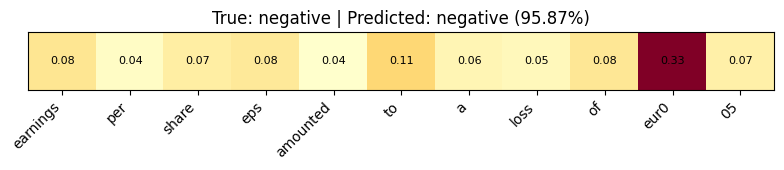

Sentence: Rapala VMC Corporation STOCK EXCHANGE RELEASE October 10, 2008 at 11.45 am Kaupthing Bank Oyj ( `` Kapthing'' ) has informed Rapala VMC Corporation ( `` Rapala'' ) that it has interrupted the liquidity providing for Rapala's share for the time being.
Class probabilities: {'neutral': 0.7067487835884094, 'positive': 0.2927660644054413, 'negative': 0.00048510960186831653}
Top attention tokens: [('vmc', 0.0702284500002861), ('rapala', 0.0639842301607132), ('informed', 0.058385785669088364), ('for', 0.0577615424990654), ('providing', 0.04864271730184555)]


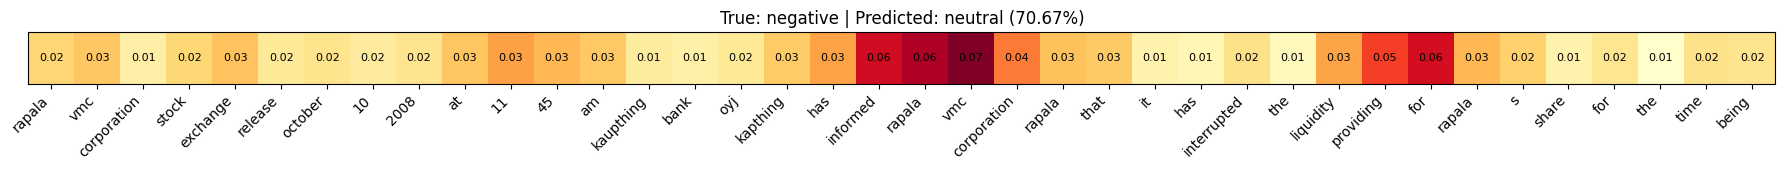

Sentence: Motorola Inc. of the United States came second with shipments of 217.4 million units for a 21.3 percent market share, followed by South Korea's Samsung Electronics Co. with shipments of 118.0 million units for an 11.6 percent share.
Class probabilities: {'neutral': 0.3979252576828003, 'positive': 0.6013516187667847, 'negative': 0.0007230950286611915}
Top attention tokens: [('for', 0.07955152541399002), ('motorola', 0.05231336131691933), ('for', 0.04262537136673927), ('percent', 0.041314173489809036), ('a', 0.03775084391236305)]


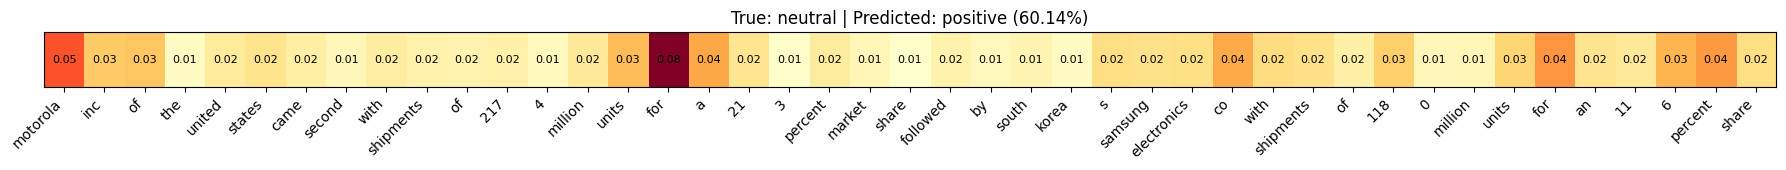

Sentence: 561,470 new shares under 2003 option rights plan Packaging company Huhtamaki Oyj reported on Monday that a total of 561,470 new shares of the company have been issued based on share subscriptions under its 2003 option rights plan.
Class probabilities: {'neutral': 0.9997316002845764, 'positive': 0.0002476382360327989, 'negative': 2.0713030608021654e-05}
Top attention tokens: [('have', 0.0941958799958229), ('been', 0.07085572928190231), ('option', 0.0501239076256752), ('subscriptions', 0.04055638611316681), ('issued', 0.039069682359695435)]


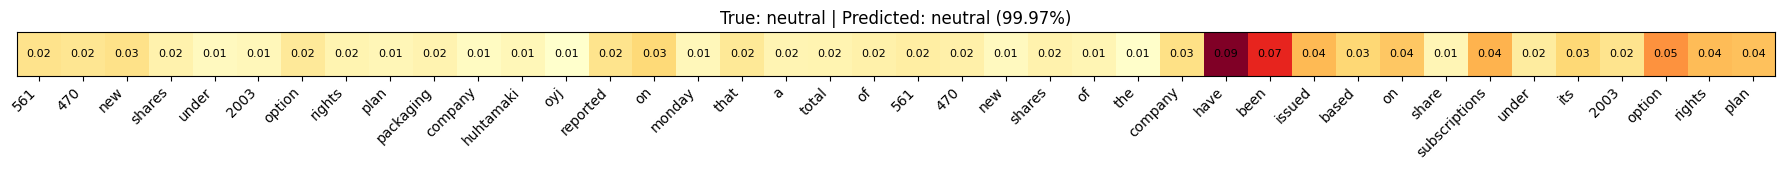

Sentence: Ragutis, which is controlled by the Finnish brewery, reported a 5.4-per-cent rise in beer sales to 10.44 million litres and held an 11.09-per-cent market share.
Class probabilities: {'neutral': 0.9356385469436646, 'positive': 0.03692937642335892, 'negative': 0.02743198536336422}
Top attention tokens: [('rise', 0.06828833371400833), ('share', 0.06024643033742905), ('09', 0.05928437411785126), ('11', 0.059052128344774246), ('cent', 0.05167074874043465)]


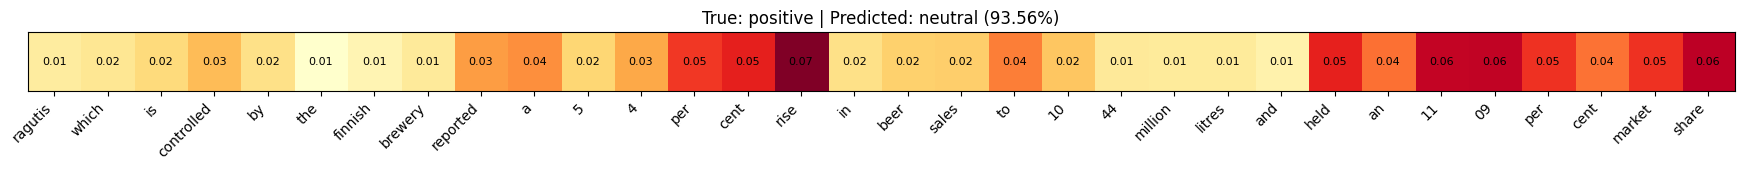

In [31]:
def plot_attention_heatmap(explanation, true_label=None):
    """Display token-level attention as a compact heatmap."""
    tokens = explanation["tokens"]
    weights = explanation["attention_weights"]

    fig_width = max(8, min(18, len(tokens) * 0.55))
    fig, ax = plt.subplots(figsize=(fig_width, 1.8))
    ax.imshow([weights], cmap="YlOrRd", aspect="auto")

    ax.set_xticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=45, ha="right")
    ax.set_yticks([])

    true_label_text = f"True: {true_label} | " if true_label is not None else ""
    ax.set_title(
        f"{true_label_text}Predicted: {explanation['predicted_label']} "
        f"({explanation['confidence']:.2%})"
    )

    for token_idx, weight in enumerate(weights):
        ax.text(token_idx, 0, f"{weight:.2f}", ha="center", va="center", fontsize=8)

    plt.tight_layout()
    plt.show()


xai_explanations = []

for _, row in xai_examples.iterrows():
    explanation = explain_sentence_attention(row["sentence"], attn_model, vocab, device)
    explanation["sentence"] = row["sentence"]
    explanation["true_label"] = row["label_name"]
    xai_explanations.append(explanation)

    print("Sentence:", row["sentence"])
    print("Class probabilities:", explanation["probabilities"])
    top_tokens = sorted(
        zip(explanation["tokens"], explanation["attention_weights"]),
        key=lambda item: item[1],
        reverse=True,
    )[:5]
    print("Top attention tokens:", top_tokens)
    plot_attention_heatmap(explanation, true_label=row["label_name"])


## Conclusion

### Evaluation Methodology

The models are evaluated using stratified train, validation, and test splits. Validation accuracy is used during training for learning-rate scheduling, early stopping, and model selection. The separate test set is held out until the end and used for the final performance comparison.

### Experimental Results

The baseline model reached a best validation accuracy of **0.7175** and a final test accuracy of **0.7216**. The Bi-LSTM with attention reached a best validation accuracy of **0.7320** and a final test accuracy of **0.7402**. This means the attention-based sequence model outperformed the embedding average-pooling baseline on both validation accuracy and test accuracy, although the margin was modest.

### Attention vs. LIME

The attention visualization is an intrinsic explanation method because the attention weights are produced inside the Bi-LSTM model during the forward pass. This makes the explanation fast and convenient: the same prediction call can return both the sentiment logits and the token weights. LIME is a post-hoc method, so it treats the model as a black box and estimates word importance by perturbing the input sentence and observing how predictions change. LIME is more model-agnostic and can be applied to many classifiers, but it is slower and depends on the perturbation strategy. Attention is useful for this project because it is simple to extract and aligns naturally with the model architecture, but attention weights should not be treated as a perfect causal explanation of the prediction.

### Limitations and Fairness

The Financial PhraseBank-style dataset is useful for sentence-level financial sentiment, but it has important limitations. The label distribution is imbalanced, with many more neutral examples than negative examples, so class weighting is needed during training. The dataset also gives isolated sentences rather than full surrounding articles or paragraphs, which means the model may miss context such as prior company performance, market conditions, or whether a statement is part of a larger positive or negative story. In addition, financial sentiment annotation can be subjective because the same sentence may affect different investors differently depending on their position, time horizon, or industry knowledge.

### Reproducibility

The notebook uses fixed random seeds for data splitting, model initialization, and dataloader shuffling. For stronger reproducibility, future versions could document package versions and pin the dataset source.

### Final Conclusion

This notebook demonstrates a complete workflow for financial news sentiment classification, from data preparation through baseline comparison, Bi-LSTM attention modeling, and token-level XAI visualization. The final result supports the project goal: the Bi-LSTM with attention learns contextual sequence patterns that improve over the baseline while also providing interpretable attention weights for selected financial sentences.


